In [ ]:
# title and stuff

In [53]:
# import packages

import copy
import glob
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

import os
import pandas as pd


In [ ]:
AREA_NAME = "Big_Bend_Bouldering"

In [ ]:
# define functions for data analysis

def find_area_csvs(area_name, data_dir='data'):
    """
    Searches data_dir for CSV files whose names contain area_name.
    Groups matches by file type (the suffix after area_name in the filename),
    reads the most recent file of each type into a pandas DataFrame, and
    returns a dict mapping file type suffix to DataFrame.

    Args:
        area_name: The area name string to search for (e.g. AREA_NAME). Type is string.
        data_dir:  Subdirectory to search. Default is 'data'.

    Returns:
        dict mapping file type suffix (str) to pandas DataFrame.
        Example: {'area_df_with_stats': <DataFrame>, 'user_info_df': <DataFrame>}
    """
    pattern = os.path.join(data_dir, f'*{area_name}*.csv')
    matches = glob.glob(pattern)

    if not matches:
        print(f"No CSV files found in '{data_dir}' containing '{area_name}'.")
        return {}

    # Group by the suffix that follows area_name in the filename
    groups = {}
    for path in matches:
        filename = os.path.basename(path)
        after = filename.split(area_name, 1)[-1].lstrip('_').removesuffix('.csv')
        groups.setdefault(after, []).append(path)

    # Read the most recent file per type into a DataFrame
    result = {}
    for suffix, paths in groups.items():
        most_recent = sorted(paths)[-1]
        result[suffix] = pd.read_csv(most_recent)
        print(f"Loaded '{suffix}' from {most_recent}  ({len(result[suffix])} rows)")

    return result

In [13]:
dfs = find_area_csvs(area_name = AREA_NAME, data_dir='data')

Loaded 'area_df_with_stats' from data/20260331_111950_Big_Bend_Bouldering_area_df_with_stats.csv  (8130 rows)
Loaded 'user_info_df' from data/20260331_125929_Big_Bend_Bouldering_user_info_df.csv  (2029 rows)
Loaded 'unique_user_df' from data/20260331_111959_Big_Bend_Bouldering_unique_user_df.csv  (2029 rows)
Loaded 'area_df_with_user_info' from data/20260331_175013_Big_Bend_Bouldering_area_df_with_user_info.csv  (8130 rows)


In [14]:
dfs.keys()

dict_keys(['area_df_with_stats', 'user_info_df', 'unique_user_df', 'area_df_with_user_info'])

In [ ]:
area_df = dfs['area_df_with_user_info']
#user_info_df

In [ ]:
# make relevant plots.... should I make a plot functions file too? Think about it. 




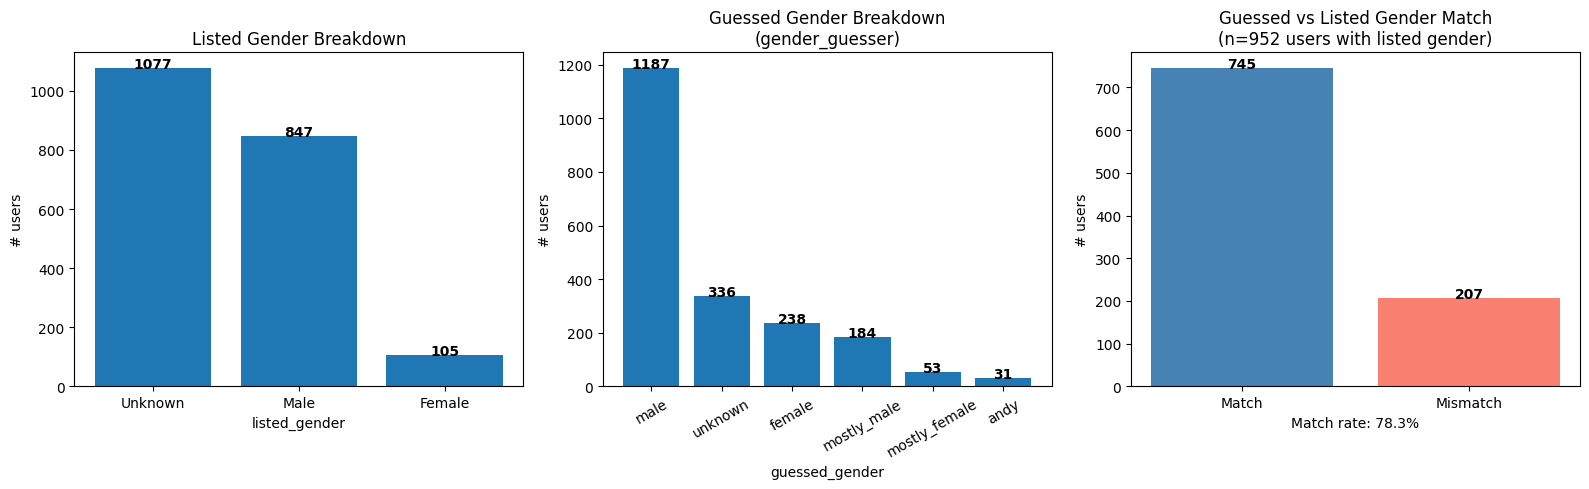

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: listed_gender breakdown ---
listed_counts = dfs['user_info_df']['listed_gender'].fillna('Unknown').value_counts()
axes[0].bar(listed_counts.index, listed_counts.values)
axes[0].set_title('Listed Gender Breakdown')
axes[0].set_xlabel('listed_gender')
axes[0].set_ylabel('# users')
for i, v in enumerate(listed_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 2: guessed_gender breakdown ---
guessed_counts = dfs['user_info_df']['guessed_gender'].fillna('unknown').value_counts()
axes[1].bar(guessed_counts.index, guessed_counts.values)
axes[1].set_title('Guessed Gender Breakdown\n(gender_guesser)')
axes[1].set_xlabel('guessed_gender')
axes[1].set_ylabel('# users')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(guessed_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 3: guessed vs listed match rate ---
# Only compare users who have a listed gender
has_listed = dfs['user_info_df'].dropna(subset=['listed_gender', 'guessed_gender']).copy()

# Normalize: map guessed_gender to Male/Female for comparison
guess_map = {
    'male': 'Male', 'mostly_male': 'Male',
    'female': 'Female', 'mostly_female': 'Female',
    'andy': 'Unknown', 'unknown': 'Unknown'
}
has_listed['guessed_normalized'] = has_listed['guessed_gender'].map(guess_map).fillna('Unknown')
has_listed['match'] = has_listed['listed_gender'] == has_listed['guessed_normalized']

match_counts = has_listed['match'].value_counts()
match_labels = ['Match' if k else 'Mismatch' for k in match_counts.index]
axes[2].bar(match_labels, match_counts.values, color=['steelblue', 'salmon'])
axes[2].set_title(f'Guessed vs Listed Gender Match\n(n={len(has_listed)} users with listed gender)')
axes[2].set_ylabel('# users')
for i, v in enumerate(match_counts.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

match_rate = has_listed['match'].mean()
axes[2].set_xlabel(f'Match rate: {match_rate:.1%}')

plt.tight_layout()
plt.show()

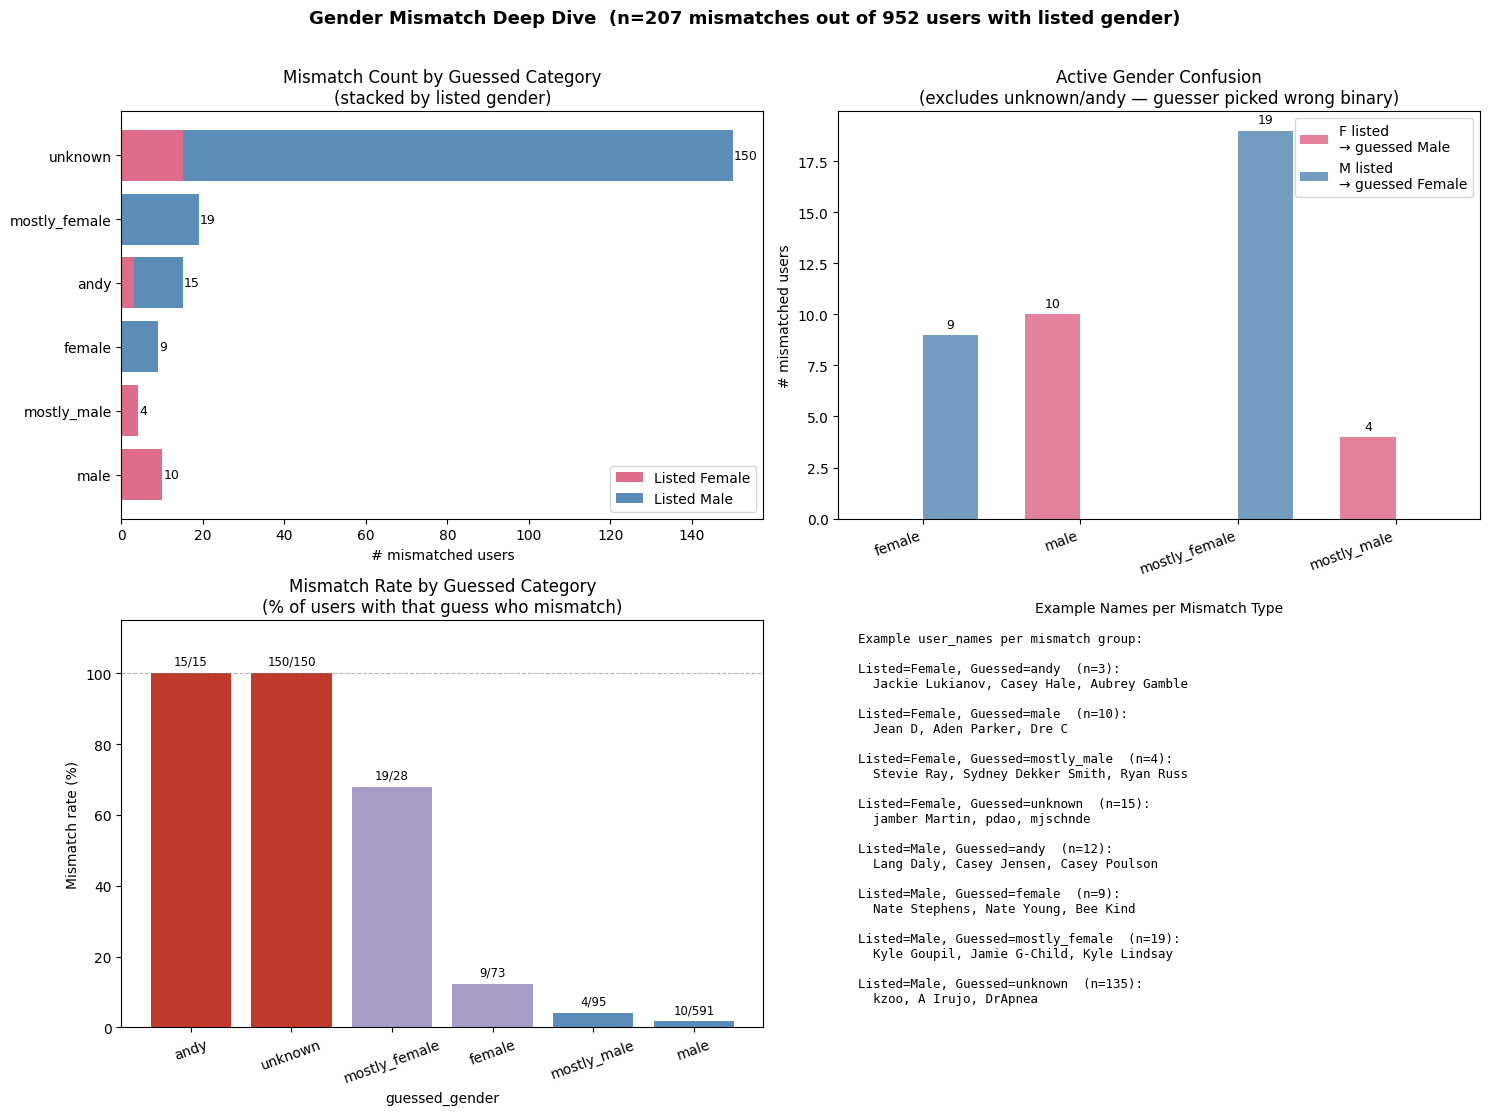

In [42]:
# ── Mismatch Detail Analysis ──────────────────────────────────────────────────
# Re-derive has_listed / match if Cell 15 hasn't run yet
if 'has_listed' not in dir() or 'match' not in has_listed.columns:
    has_listed = dfs['user_info_df'].dropna(subset=['listed_gender', 'guessed_gender']).copy()
    guess_map = {
        'male': 'Male', 'mostly_male': 'Male',
        'female': 'Female', 'mostly_female': 'Female',
        'andy': 'Unknown', 'unknown': 'Unknown'
    }
    has_listed['guessed_normalized'] = has_listed['guessed_gender'].map(guess_map).fillna('Unknown')
    has_listed['match'] = has_listed['listed_gender'] == has_listed['guessed_normalized']

mismatches = has_listed[~has_listed['match']].copy()
n_mismatch = len(mismatches)

COLOR_F = '#e06c8b'
COLOR_M = '#5b8db8'

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    f'Gender Mismatch Deep Dive  (n={n_mismatch} mismatches out of {len(has_listed)} users with listed gender)',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Subplot 1 (top-left): Mismatch count stacked by listed_gender ─────────────
ax1 = axes[0, 0]

pivot = (
    mismatches
    .groupby(['guessed_gender', 'listed_gender'])
    .size()
    .unstack(fill_value=0)
)
for col in ['Female', 'Male']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot.sort_values('Male', ascending=True)

bar_positions = list(range(len(pivot)))
ax1.barh(bar_positions, pivot['Female'], color=COLOR_F, label='Listed Female')
ax1.barh(bar_positions, pivot['Male'], left=pivot['Female'], color=COLOR_M, label='Listed Male')
ax1.set_yticks(bar_positions)
ax1.set_yticklabels(pivot.index)
ax1.set_xlabel('# mismatched users')
ax1.set_title('Mismatch Count by Guessed Category\n(stacked by listed gender)')
ax1.legend(loc='lower right')
for i, (f_val, m_val) in enumerate(zip(pivot['Female'], pivot['Male'])):
    total = f_val + m_val
    ax1.text(total + 0.3, i, str(total), va='center', fontsize=9)

# ── Subplot 2 (top-right): Active gender confusion (excludes unknown/andy) ─────
ax2 = axes[0, 1]

active_mis = mismatches[mismatches['guessed_normalized'] != 'Unknown']
f_to_m = active_mis[active_mis['listed_gender'] == 'Female'].groupby('guessed_gender').size()
m_to_f = active_mis[active_mis['listed_gender'] == 'Male'].groupby('guessed_gender').size()

confusion_df = pd.DataFrame({
    'F listed\n→ guessed Male': f_to_m,
    'M listed\n→ guessed Female': m_to_f,
}).fillna(0).astype(int)

x = list(range(len(confusion_df)))
width = 0.35
for j, (col, color) in enumerate(zip(confusion_df.columns, [COLOR_F, COLOR_M])):
    bars = ax2.bar(
        [xi + j * width for xi in x],
        confusion_df[col],
        width=width, label=col, color=color, alpha=0.85
    )
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.2,
                     str(int(h)), ha='center', va='bottom', fontsize=9)

ax2.set_xticks([xi + width / 2 for xi in x])
ax2.set_xticklabels(confusion_df.index, rotation=20, ha='right')
ax2.set_ylabel('# mismatched users')
ax2.set_title('Active Gender Confusion\n(excludes unknown/andy — guesser picked wrong binary)')
ax2.legend()

# ── Subplot 3 (bottom-left): Mismatch rate per guessed_gender category ─────────
ax3 = axes[1, 0]

rate_data = []
for cat, grp in has_listed.groupby('guessed_gender'):
    n_total = len(grp)
    n_mis = (~grp['match']).sum()
    rate_data.append({'guessed_gender': cat, 'n_total': n_total,
                      'n_mismatch': n_mis, 'rate': n_mis / n_total})
rate_df = pd.DataFrame(rate_data).sort_values('rate', ascending=False)

bar_colors = ['#c0392b' if r >= 1.0 else COLOR_M if r < 0.05 else '#a89cc8' for r in rate_df['rate']]
bars3 = ax3.bar(rate_df['guessed_gender'], rate_df['rate'] * 100, color=bar_colors)
ax3.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax3.set_ylim(0, 115)
ax3.set_ylabel('Mismatch rate (%)')
ax3.set_xlabel('guessed_gender')
ax3.set_title('Mismatch Rate by Guessed Category\n(% of users with that guess who mismatch)')
ax3.tick_params(axis='x', rotation=20)
for bar, row in zip(bars3, rate_df.itertuples()):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{row.n_mismatch}/{row.n_total}',
        ha='center', va='bottom', fontsize=8.5
    )

# ── Subplot 4 (bottom-right): Example names text table ────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')

lines = ['Example user_names per mismatch group:\n']
name_groups = (
    mismatches
    .groupby(['listed_gender', 'guessed_gender'])['user_name']
    .apply(lambda x: ', '.join(x.head(3)))
)
for (listed, guessed_raw), names in name_groups.items():
    n = len(mismatches[
        (mismatches['listed_gender'] == listed) &
        (mismatches['guessed_gender'] == guessed_raw)
    ])
    lines.append(f'Listed={listed}, Guessed={guessed_raw}  (n={n}):')
    lines.append(f'  {names}')
    lines.append('')

ax4.text(
    0.03, 0.97, '\n'.join(lines),
    transform=ax4.transAxes,
    va='top', ha='left',
    fontsize=9,
    fontfamily='monospace'
)
ax4.set_title('Example Names per Mismatch Type', fontsize=10)

plt.tight_layout()
plt.show()

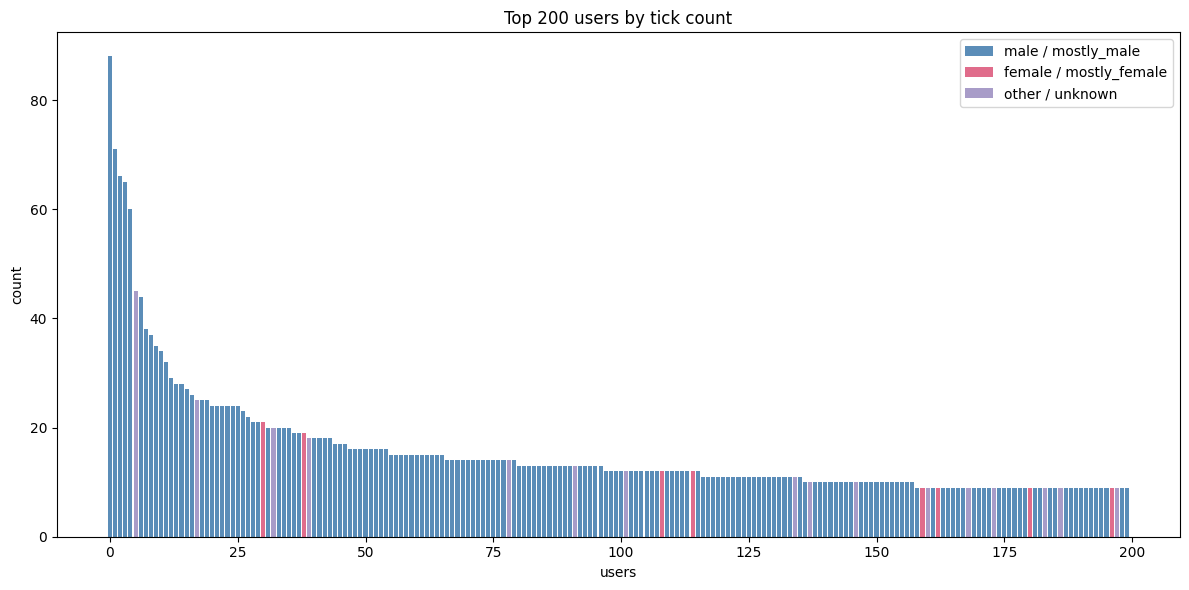

Total unique users: 1998
user.name
ben jammin             88
Wyatt Murphy           71
Jackson Birrell        66
Marcus St Jolie        65
Christian Prellwitz    60
Anonymous              45
jakobi                 44
Kyle Goupil            38
Eric Odenthal          37
Sean Patrick           35
Name: count, dtype: int64


In [30]:

vc = area_df['user.name'].value_counts()
top_n = 200

top_users = vc.head(top_n)

# Map each username to their likely_gender color
gender_color_map = {'male': '#5b8db8', 'mostly_male': '#5b8db8',
                    'female': '#e06c8b', 'mostly_female': '#e06c8b'}
user_gender = area_df.drop_duplicates('user.name').set_index('user.name')['likely_gender']
bar_colors = [gender_color_map.get(user_gender.get(name), '#a89cc8') for name in top_users.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(top_users)), top_users.values, color=bar_colors)
ax.set_title(f'Top {top_n} users by tick count')
ax.set_xlabel('users')
ax.set_ylabel('count')
#ax.set_xticks(range(len(top_users)))
#ax.set_xticklabels(top_users.index, rotation=90, ha='center')

# Legend

legend_elements = [Patch(facecolor='#5b8db8', label='male / mostly_male'),
                   Patch(facecolor='#e06c8b', label='female / mostly_female'),
                   Patch(facecolor='#a89cc8', label='other / unknown')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f'Total unique users: {vc.shape[0]}')
print(vc.head(10))

16 routes meet the minimum rating threshold (>=3 female, >=3 male)


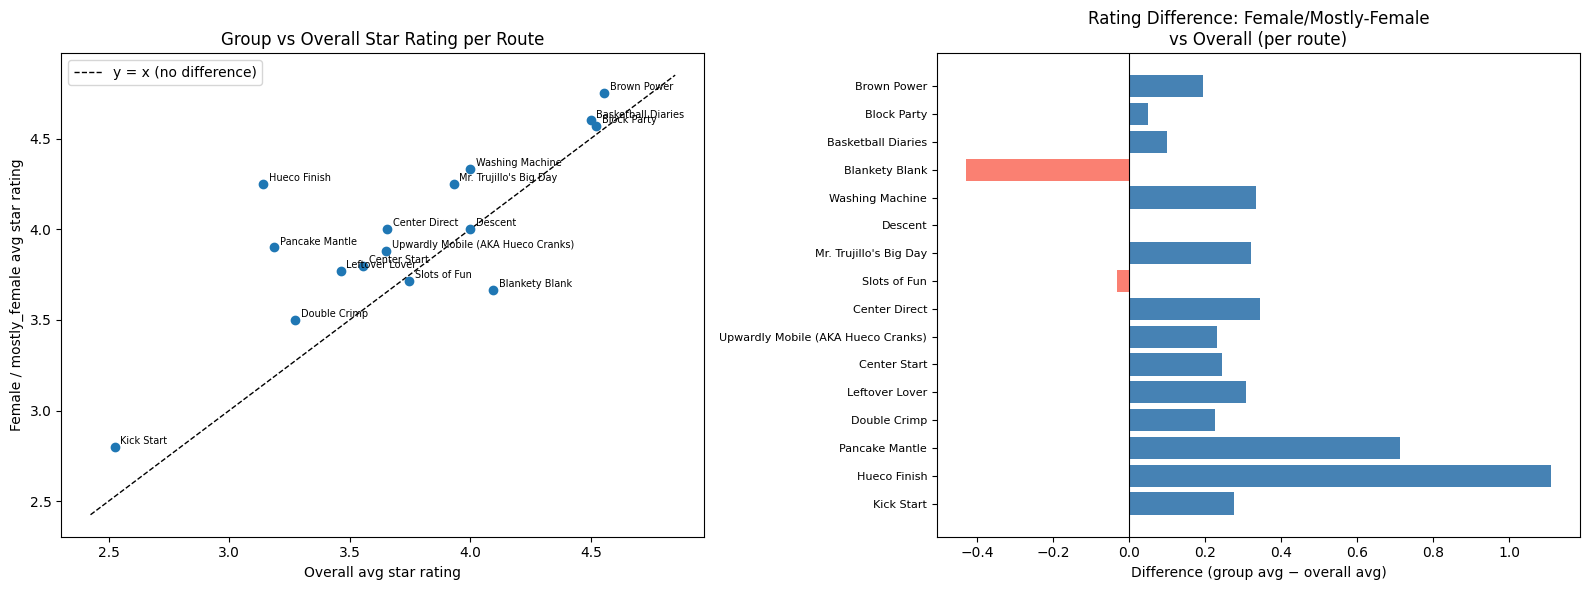

                                    overall_avg  group_avg  diff
Route                                                           
Kick Start                                 2.53       2.80  0.27
Hueco Finish                               3.14       4.25  1.11
Pancake Mantle                             3.19       3.90  0.71
Double Crimp                               3.28       3.50  0.22
Leftover Lover                             3.46       3.77  0.31
Center Start                               3.56       3.80  0.24
Upwardly Mobile (AKA Hueco Cranks)         3.65       3.88  0.23
Center Direct                              3.66       4.00  0.34
Slots of Fun                               3.75       3.71 -0.03
Mr. Trujillo's Big Day                     3.93       4.25  0.32
Descent                                    4.00       4.00  0.00
Washing Machine                            4.00       4.33  0.33
Blankety Blank                             4.10       3.67 -0.43
Basketball Diaries       

In [43]:


target_genders = ['female', 'mostly_female']
male_genders = ['male', 'mostly_male']

column_of_interest = 'likely_gender'

min_counts = 3

# Only include routes with >= min_counts female and >= min_counts male ratings
female_counts = area_df[area_df[column_of_interest].isin(target_genders)].groupby('Route')['score'].count()
male_counts = area_df[area_df[column_of_interest].isin(male_genders)].groupby('Route')['score'].count()
qualified_routes = female_counts[female_counts >= min_counts].index.intersection(male_counts[male_counts >= min_counts].index)
print(f"{len(qualified_routes)} routes meet the minimum rating threshold (>={min_counts} female, >={min_counts} male)")

# Per-route averages (qualified routes only)
overall_avg = area_df[area_df['Route'].isin(qualified_routes)].groupby('Route')['score'].mean().rename('overall_avg')
group_avg = (
    area_df[area_df[column_of_interest].isin(target_genders) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('group_avg')
)

compare_df = pd.concat([overall_avg, group_avg], axis=1).dropna()
compare_df['diff'] = compare_df['group_avg'] - compare_df['overall_avg']
compare_df = compare_df.sort_values('overall_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter — group avg vs overall avg per route ---
ax = axes[0]
ax.scatter(compare_df['overall_avg'], compare_df['group_avg'], zorder=3)
lims = [
    min(compare_df['overall_avg'].min(), compare_df['group_avg'].min()) - 0.1,
    max(compare_df['overall_avg'].max(), compare_df['group_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in compare_df.iterrows():
    ax.annotate(route, (row['overall_avg'], row['group_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Overall avg star rating')
ax.set_ylabel('Female / mostly_female avg star rating')
ax.set_title('Group vs Overall Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (group_avg - overall_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in compare_df['diff']]
bars = ax.barh(compare_df.index, compare_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (group avg − overall avg)')
ax.set_title('Rating Difference: Female/Mostly-Female\nvs Overall (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(compare_df[['overall_avg', 'group_avg', 'diff']].round(2))

16 routes meet the minimum rating threshold (>=3 female, >=3 male)


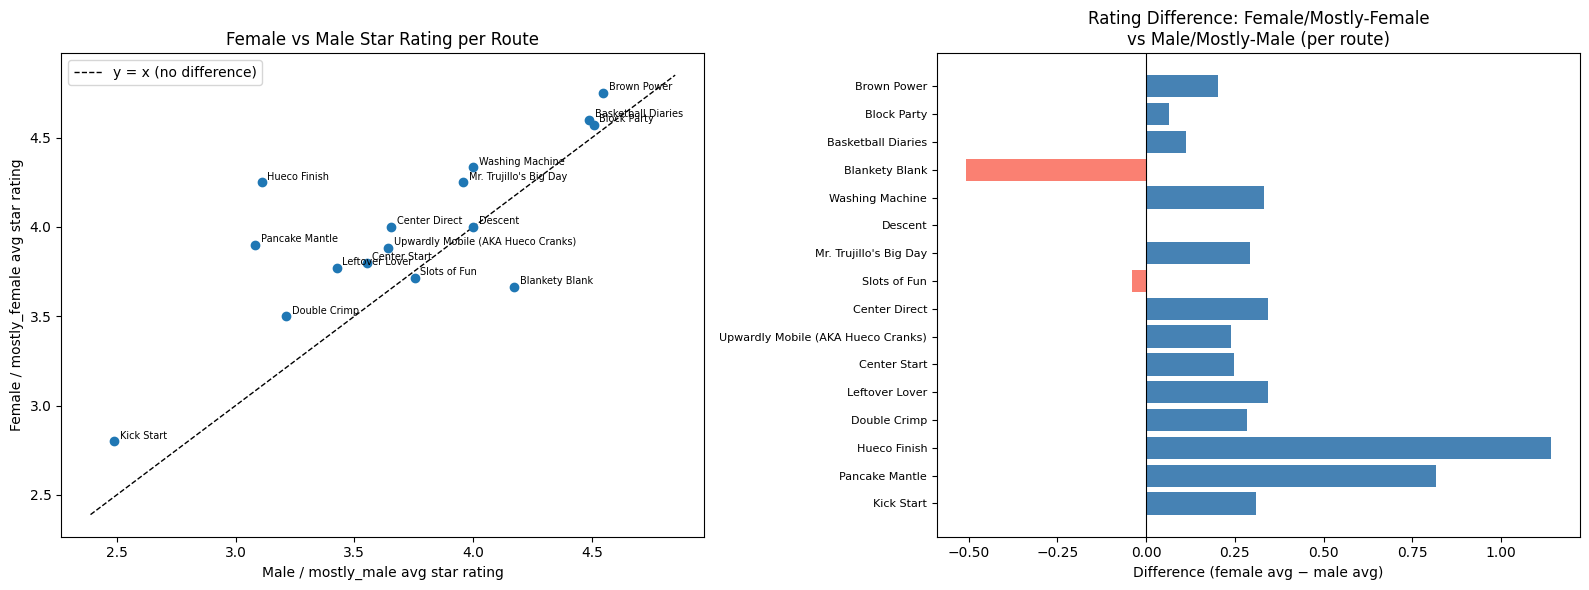

                                    female_avg  male_avg  diff
Route                                                         
Kick Start                                2.80      2.49  0.31
Pancake Mantle                            3.90      3.08  0.82
Hueco Finish                              4.25      3.11  1.14
Double Crimp                              3.50      3.21  0.29
Leftover Lover                            3.77      3.43  0.34
Center Start                              3.80      3.55  0.25
Upwardly Mobile (AKA Hueco Cranks)        3.88      3.64  0.24
Center Direct                             4.00      3.66  0.34
Slots of Fun                              3.71      3.75 -0.04
Mr. Trujillo's Big Day                    4.25      3.96  0.29
Descent                                   4.00      4.00  0.00
Washing Machine                           4.33      4.00  0.33
Blankety Blank                            3.67      4.17 -0.51
Basketball Diaries                        4.60      4.4

In [44]:
female_genders = ['female', 'mostly_female']
male_genders = ['male', 'mostly_male']

column_of_interest = 'likely_gender'

min_counts = 2

# Only include routes with >= 3 female and >= 3 male ratings
female_counts = area_df[area_df[column_of_interest].isin(['female', 'mostly_female'])].groupby('Route')['score'].count()
male_counts = area_df[area_df[column_of_interest].isin(['male', 'mostly_male'])].groupby('Route')['score'].count()
qualified_routes = female_counts[female_counts >= 3].index.intersection(male_counts[male_counts >= 3].index)
print(f"{len(qualified_routes)} routes meet the minimum rating threshold (>=3 female, >=3 male)")

female_avg = (
    area_df[area_df[column_of_interest].isin(female_genders) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('female_avg')
)
male_avg = (
    area_df[area_df[column_of_interest].isin(male_genders) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('male_avg')
)

fm_df = pd.concat([female_avg, male_avg], axis=1).dropna()
fm_df['diff'] = fm_df['female_avg'] - fm_df['male_avg']
fm_df = fm_df.sort_values('male_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter ---
ax = axes[0]
ax.scatter(fm_df['male_avg'], fm_df['female_avg'], zorder=3)
lims = [
    min(fm_df['male_avg'].min(), fm_df['female_avg'].min()) - 0.1,
    max(fm_df['male_avg'].max(), fm_df['female_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in fm_df.iterrows():
    ax.annotate(route, (row['male_avg'], row['female_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Male / mostly_male avg star rating')
ax.set_ylabel('Female / mostly_female avg star rating')
ax.set_title('Female vs Male Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (female_avg - male_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in fm_df['diff']]
ax.barh(fm_df.index, fm_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (female avg − male avg)')
ax.set_title('Rating Difference: Female/Mostly-Female\nvs Male/Mostly-Male (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(fm_df[['female_avg', 'male_avg', 'diff']].round(2))

21 routes meet the minimum rating threshold (>=3 female, >=3 male)


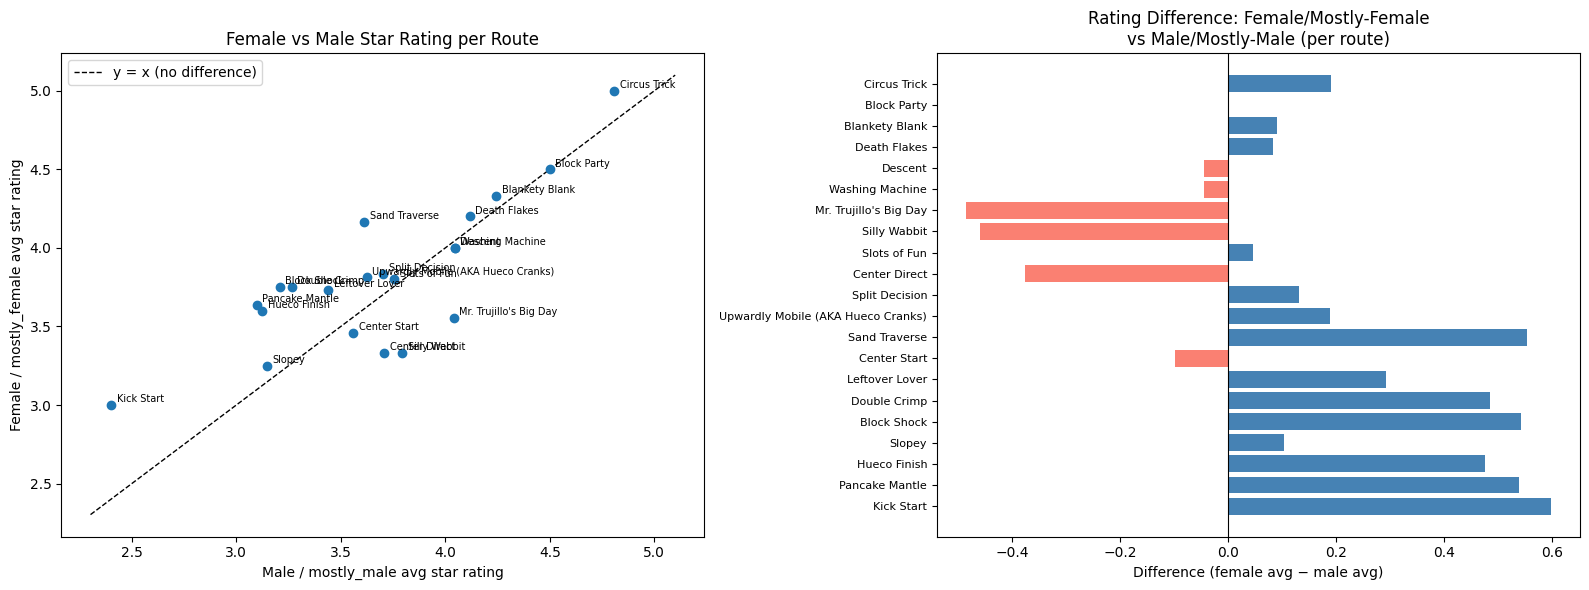

                                    female_avg  male_avg  diff
Route                                                         
Kick Start                                3.00      2.40  0.60
Pancake Mantle                            3.64      3.10  0.54
Hueco Finish                              3.60      3.12  0.48
Slopey                                    3.25      3.15  0.10
Block Shock                               3.75      3.21  0.54
Double Crimp                              3.75      3.26  0.49
Leftover Lover                            3.73      3.44  0.29
Center Start                              3.46      3.56 -0.10
Sand Traverse                             4.17      3.61  0.55
Upwardly Mobile (AKA Hueco Cranks)        3.81      3.62  0.19
Split Decision                            3.83      3.70  0.13
Center Direct                             3.33      3.71 -0.38
Slots of Fun                              3.80      3.75  0.05
Silly Wabbit                              3.33      3.7

In [32]:
# Only include routes with >= 3 female and >= 3 male ratings
female_counts = area_df[area_df['guessed_gender'].isin(['female', 'mostly_female'])].groupby('Route')['score'].count()
male_counts = area_df[area_df['guessed_gender'].isin(['male', 'mostly_male'])].groupby('Route')['score'].count()
qualified_routes = female_counts[female_counts >= 3].index.intersection(male_counts[male_counts >= 3].index)
print(f"{len(qualified_routes)} routes meet the minimum rating threshold (>=3 female, >=3 male)")

female_avg = (
    area_df[area_df['guessed_gender'].isin(['female', 'mostly_female']) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('female_avg')
)
male_avg = (
    area_df[area_df['guessed_gender'].isin(['male', 'mostly_male']) & area_df['Route'].isin(qualified_routes)]
    .groupby('Route')['score'].mean()
    .rename('male_avg')
)

fm_df = pd.concat([female_avg, male_avg], axis=1).dropna()
fm_df['diff'] = fm_df['female_avg'] - fm_df['male_avg']
fm_df = fm_df.sort_values('male_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter ---
ax = axes[0]
ax.scatter(fm_df['male_avg'], fm_df['female_avg'], zorder=3)
lims = [
    min(fm_df['male_avg'].min(), fm_df['female_avg'].min()) - 0.1,
    max(fm_df['male_avg'].max(), fm_df['female_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in fm_df.iterrows():
    ax.annotate(route, (row['male_avg'], row['female_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Male / mostly_male avg star rating')
ax.set_ylabel('Female / mostly_female avg star rating')
ax.set_title('Female vs Male Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (female_avg - male_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in fm_df['diff']]
ax.barh(fm_df.index, fm_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (female avg − male avg)')
ax.set_title('Rating Difference: Female/Mostly-Female\nvs Male/Mostly-Male (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(fm_df[['female_avg', 'male_avg', 'diff']].round(2))

In [50]:
area_df['comment'].dropna().drop_duplicates(keep = 'first')

1                                               Half way 
2                                                        
9        half way up above a single medium pad. felt t...
18                                 A definitely exciting!
23                                          chickened out
                              ...                        
8067     WSU School Trip 2023: Pretty difficult projec...
8075                                 3rd outdoor boulder!
8079                                             Fun hugs
8092     did Dom’s fun one hold extension to the east ...
8125     LH lower flake, RH same side pull to add an e...
Name: comment, Length: 870, dtype: object

In [63]:
filtered_df = copy.deepcopy(area_df)
filtered_df.dropna(subset = ['comment'], inplace = True)
filtered_df[filtered_df['comment'].str.contains('short | tall | reachy')][['Route', 'likely_gender', 'comment']].to_csv('data/20260401_Big_Bend_Bouldering_comments.csv', index = False)